# **Google Play Store Project**
EDA Descriptive and Inferential Statistics

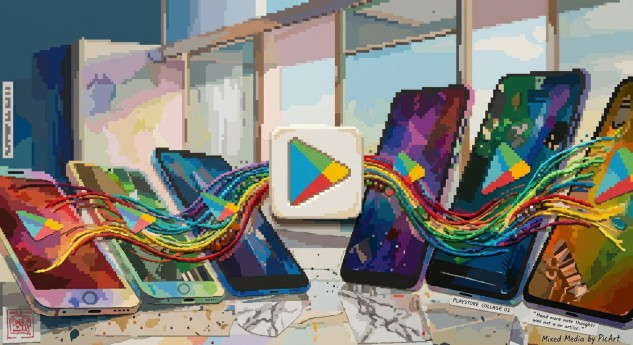

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv("googleplaystore.csv")
df1.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df2 = pd.read_csv("googleplaystore_user_reviews.csv")
df2.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
df1.shape

(10841, 13)

In [5]:
df2.shape

(72964, 5)

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72964 entries, 0 to 72963
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     72964 non-null  object 
 1   Translated_Review       43092 non-null  object 
 2   Sentiment               43098 non-null  object 
 3   Sentiment_Polarity      43098 non-null  float64
 4   Sentiment_Subjectivity  43097 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.8+ MB


In [8]:
df1.isnull().sum().sort_values(ascending=False)

,0
Rating,1474
Current Ver,8
Android Ver,3
Content Rating,1
Type,1
Size,0
Reviews,0
Category,0
App,0
Price,0


In [9]:
df1.duplicated().sum()

np.int64(483)

In [10]:
df1['App'].duplicated().sum()

np.int64(1181)

In [11]:
df1[df1['App'].duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,FarmersOnly Dating,DATING,3.0,1145,1.4M,"100,000+",Free,0,Mature 17+,Dating,"February 25, 2016",2.2,4.0 and up
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0M,"1,000,000+",Free,0,Everyone,Communication,"July 6, 2018",5.2,5.0 and up
10730,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up
10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12M,"1,000,000+",Free,0,Everyone,Shopping,"July 30, 2018",3.9,4.4 and up


In [12]:
df1['Reviews'].sample(10)

,Reviews
8950,770
10217,182
7394,0
3794,479594
1740,5566805
744,248912
409,15880
10017,728
4437,324
8354,0


In [13]:
df1['Reviews'] = pd.to_numeric(df1['Reviews'], errors='coerce')

In [14]:
df1['Installs'].unique()[:20]

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+'], dtype=object)

In [15]:
df1['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [16]:
df1['Size'].sample(20)

,Size
10405,15M
4689,10M
5869,Varies with device
4967,14M
9476,59M
1560,36M
6022,3.3M
5265,32M
3718,26M
6845,Varies with device


In [17]:
df1['Rating'].describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [18]:
df1[df1['Rating'] > 5]
# needed to be removed as rating scale needs to be 0 to 5 and its just 1 so i can remove

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [19]:
df1['Type'].value_counts(dropna=False)

,count
Type,
Free,10039
Paid,800
NaN,1
0,1


In [20]:
df1['Content Rating'].value_counts(dropna=False)

,count
Content Rating,
Everyone,8714
Teen,1208
Mature 17+,499
Everyone 10+,414
Adults only 18+,3
Unrated,2
NaN,1


In [21]:
df2.isnull().sum().sort_values(ascending=False)

,0
Translated_Review,29872
Sentiment_Subjectivity,29867
Sentiment,29866
Sentiment_Polarity,29866
App,0


Data Cleaning Steps

1. Remove corrupted records where Rating > 5 because Play Store ratings should be between 0 and 5 only.
2. Convert Reviews from object to numeric because it represents the number of reviews.
3. Clean Installs column by removing ',' and '+' signs and convert it to numeric.
4. Clean Price column by removing '$' sign and convert it to numeric.
5. Clean Size column:
   - Convert values ending with M to MB
   - Convert values ending with k to MB
   - Replace 'Varies with device' with missing values

6. Investigating and handling missing values in Rating, Type, Current Ver and Android Ver.
7. Investigating duplicate apps and remove duplicate records if necessary.
8. Validate Type column because it should contain only Free or Paid.
9. Validate Content Rating column and check for unexpected categories.
10. Convert columns to appropriate data types for statistical analysis and machine learning.

In [22]:
df1 = df1[df1['Rating'] <= 5]
df1.shape

(9366, 13)

In [23]:
df1['Type'].unique()

array(['Free', 'Paid'], dtype=object)

In [24]:
df1['Reviews'] = df1['Reviews'].astype(int)
df1['Reviews'].dtype

dtype('int64')

In [25]:
df1['Installs'] = df1['Installs'].apply(lambda x: x.replace(',', '').replace('+', '') if isinstance(x, str) else x)
df1['Installs'] = pd.to_numeric(df1['Installs'])

In [26]:
df1['Price'] = df1['Price'].apply(lambda x: x.replace('$', '') if isinstance(x, str) else x)
df1['Price'] = pd.to_numeric(df1['Price'])

In [27]:
df1['Size'] = df1['Size'].replace('Varies with device', np.nan)

k_mask = df1['Size'].astype(str).str.contains('k', na=False)
df1.loc[k_mask, 'Size'] = pd.to_numeric(df1.loc[k_mask, 'Size'].astype(str).str.replace('k', '')) / 1024

m_mask = df1['Size'].astype(str).str.contains('M', na=False)
df1.loc[m_mask, 'Size'] = pd.to_numeric(df1.loc[m_mask, 'Size'].astype(str).str.replace('M', ''))

df1['Size'] = pd.to_numeric(df1['Size'], errors='coerce')

In [28]:
df1['Size'].isnull().sum()

# varies with device was treated as missing because no exact application size was available

np.int64(1637)

In [29]:
df1.shape

(9366, 13)

In [30]:
df1['Rating'].isnull().sum()
# there is no null in rating

df1['Rating'].dtype

df1[df1['Current Ver'].isnull()]

df1[df1['Android Ver'].isnull()]

# current ver having 4 null values and android ver is having 2 null values in total = 6 and as compared to shape its very less so drop is justified
df1 = df1.dropna(subset=['Current Ver', 'Android Ver'])

In [31]:
duplicates = df1[df1.duplicated(subset=['App'], keep=False)].sort_values(by='App')
duplicates

# these are genuine duplicates

df1 = df1.drop_duplicates(subset=['App'])
df1.shape

(8190, 13)

In [32]:
df1['Type'] = df1['Type'].str.strip()
df1['Type'] = df1['Type'].astype('category')
df1['Type'].value_counts()

,count
Type,
Free,7588
Paid,602


In [33]:
df1['Content Rating'].unique()
df1['Content Rating'] = df1['Content Rating'].astype('category')
df1['Content Rating'].value_counts()

,count
Content Rating,
Everyone,6612
Teen,912
Mature 17+,357
Everyone 10+,305
Adults only 18+,3
Unrated,1


In [34]:
df1 = df1[df1['Content Rating'] != 'Unrated']
df1['Content Rating'].value_counts()
df1['Content Rating'].astype('category')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8189 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   App             8189 non-null   object  
 1   Category        8189 non-null   object  
 2   Rating          8189 non-null   float64 
 3   Reviews         8189 non-null   int64   
 4   Size            7020 non-null   float64 
 5   Installs        8189 non-null   int64   
 6   Type            8189 non-null   category
 7   Price           8189 non-null   float64 
 8   Content Rating  8189 non-null   category
 9   Genres          8189 non-null   object  
 10  Last Updated    8189 non-null   object  
 11  Current Ver     8189 non-null   object  
 12  Android Ver     8189 non-null   object  
dtypes: category(2), float64(3), int64(2), object(6)
memory usage: 784.0+ KB


In [35]:
df1['Genres'].unique()
df1['Genres'] = df1['Genres'].astype('category')

In [36]:
df1['Last Updated'] = pd.to_datetime(df1['Last Updated'])

In [37]:
df1.shape

(8189, 13)

In [38]:
df2 = pd.read_csv("googleplaystore_user_reviews.csv")
df2.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [39]:
df2.shape

(72964, 5)

In [40]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72964 entries, 0 to 72963
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     72964 non-null  object 
 1   Translated_Review       43092 non-null  object 
 2   Sentiment               43098 non-null  object 
 3   Sentiment_Polarity      43098 non-null  float64
 4   Sentiment_Subjectivity  43097 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.8+ MB


In [41]:
df2.isnull().sum()

,0
App,0
Translated_Review,29872
Sentiment,29866
Sentiment_Polarity,29866
Sentiment_Subjectivity,29867


In [42]:
df2.duplicated().sum()

np.int64(42284)

In [43]:
df2['Sentiment'].value_counts(dropna=False)

,count
Sentiment,
NaN,29866
Positive,27397
Negative,9613
Neutral,6087
0.43333333333333335,1


In [44]:
df2['Sentiment_Polarity'].describe()

,Sentiment_Polarity
count,43098.000000
mean,0.179330
std,0.352713
min,-1.000000
25%,0.000000
50%,0.150000
75%,0.400000
max,1.000000


In [45]:
df2['Sentiment_Subjectivity'].describe()

,Sentiment_Subjectivity
count,43097.000000
mean,0.491434
std,0.261438
min,0.000000
25%,0.350000
50%,0.513434
75%,0.650000
max,1.000000


# Data cleaning steps

1. Remove duplicate reviews.

2. Handle missing reviews.

3. Validate Sentiment values.
   Expected:
   Positive
   Negative
   Neutral

4. Validate Sentiment_Polarity range.
   Expected:
   -1 to +1

5. Validate Sentiment_Subjectivity range.
   Expected:
   0 to 1

6. Prepare app-level sentiment metrics for merging.

In [46]:
sentiment_df = (
    df2.groupby('App')
       .agg({
           'Sentiment_Polarity':'mean',
           'Sentiment_Subjectivity':'mean',
           'Translated_Review':'count'
       })
       .reset_index()
)

In [47]:
sentiment_df

,App,Sentiment_Polarity,Sentiment_Subjectivity,Translated_Review
0,10 Best Foods for You,0.470733,0.495455,194
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.392405,0.545516,40
2,11st,0.181294,0.443957,39
3,1800 Contacts - Lens Store,0.318145,0.591098,80
4,1LINE – One Line with One Touch,0.196290,0.557315,38
...,...,...,...,...
1069,Hotspot Shield Free VPN Proxy & Wi-Fi Security,0.251765,0.393284,34
1070,Hotstar,0.038178,0.493964,32
1071,Hotwire Hotel & Car Rental App,0.187029,0.459717,33
1072,Housing-Real Estate & Property,-0.021427,0.378532,21


Merging the cleaned datasets

In [48]:
df = df1.merge(sentiment_df, on='App', how='left')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity,Translated_Review
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.152652,0.64154,44.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,NaN,NaN,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,NaN,NaN,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,NaN,NaN,NaN


In [49]:
df[['Sentiment_Polarity',
    'Sentiment_Subjectivity',
    'Translated_Review']].isnull().sum()


# most apps don't have review sentiment data

,0
Sentiment_Polarity,7373
Sentiment_Subjectivity,7373
Translated_Review,7169


Descriptive Statistics

In [50]:
num_cols = ['Rating','Reviews','Size','Installs','Price']

df[num_cols].describe()

,Rating,Reviews,Size,Installs,Price
count,8189.000000,8.189000e+03,7020.000000,8.189000e+03,8189.000000
mean,4.173330,2.554665e+05,21.769355,9.172727e+06,1.038469
std,0.536724,1.986429e+06,22.732517,5.827517e+07,16.865066
min,1.000000,1.000000e+00,0.008301,1.000000e+00,0.000000
25%,4.000000,1.260000e+02,4.900000,1.000000e+04,0.000000
50%,4.300000,3.014000e+03,13.000000,1.000000e+05,0.000000
75%,4.500000,4.393500e+04,31.000000,1.000000e+06,0.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


In [51]:
max_price = df['Price'].max()
df[df['Price'] == max_price]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity,Translated_Review
3305,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.0,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,NaN,NaN,NaN


In [52]:
df[num_cols].skew()

,0
Rating,-1.744282
Reviews,24.502556
Size,1.517836
Installs,13.853319
Price,22.992029


### Rating
Strongly left-skewed (-1.74).
Most apps are rated between 4 and 5.

### Reviews
Extremely right-skewed (24.50).
Most apps have few reviews while a small number dominate engagement.

### Size
Moderately right-skewed (1.52).
Most apps are small with a few very large applications.

### Installs
Extremely right-skewed (13.85).
A small number of apps account for most downloads.

### Price
Extremely right-skewed (22.99).
Most apps are free while a few expensive apps create the long tail.

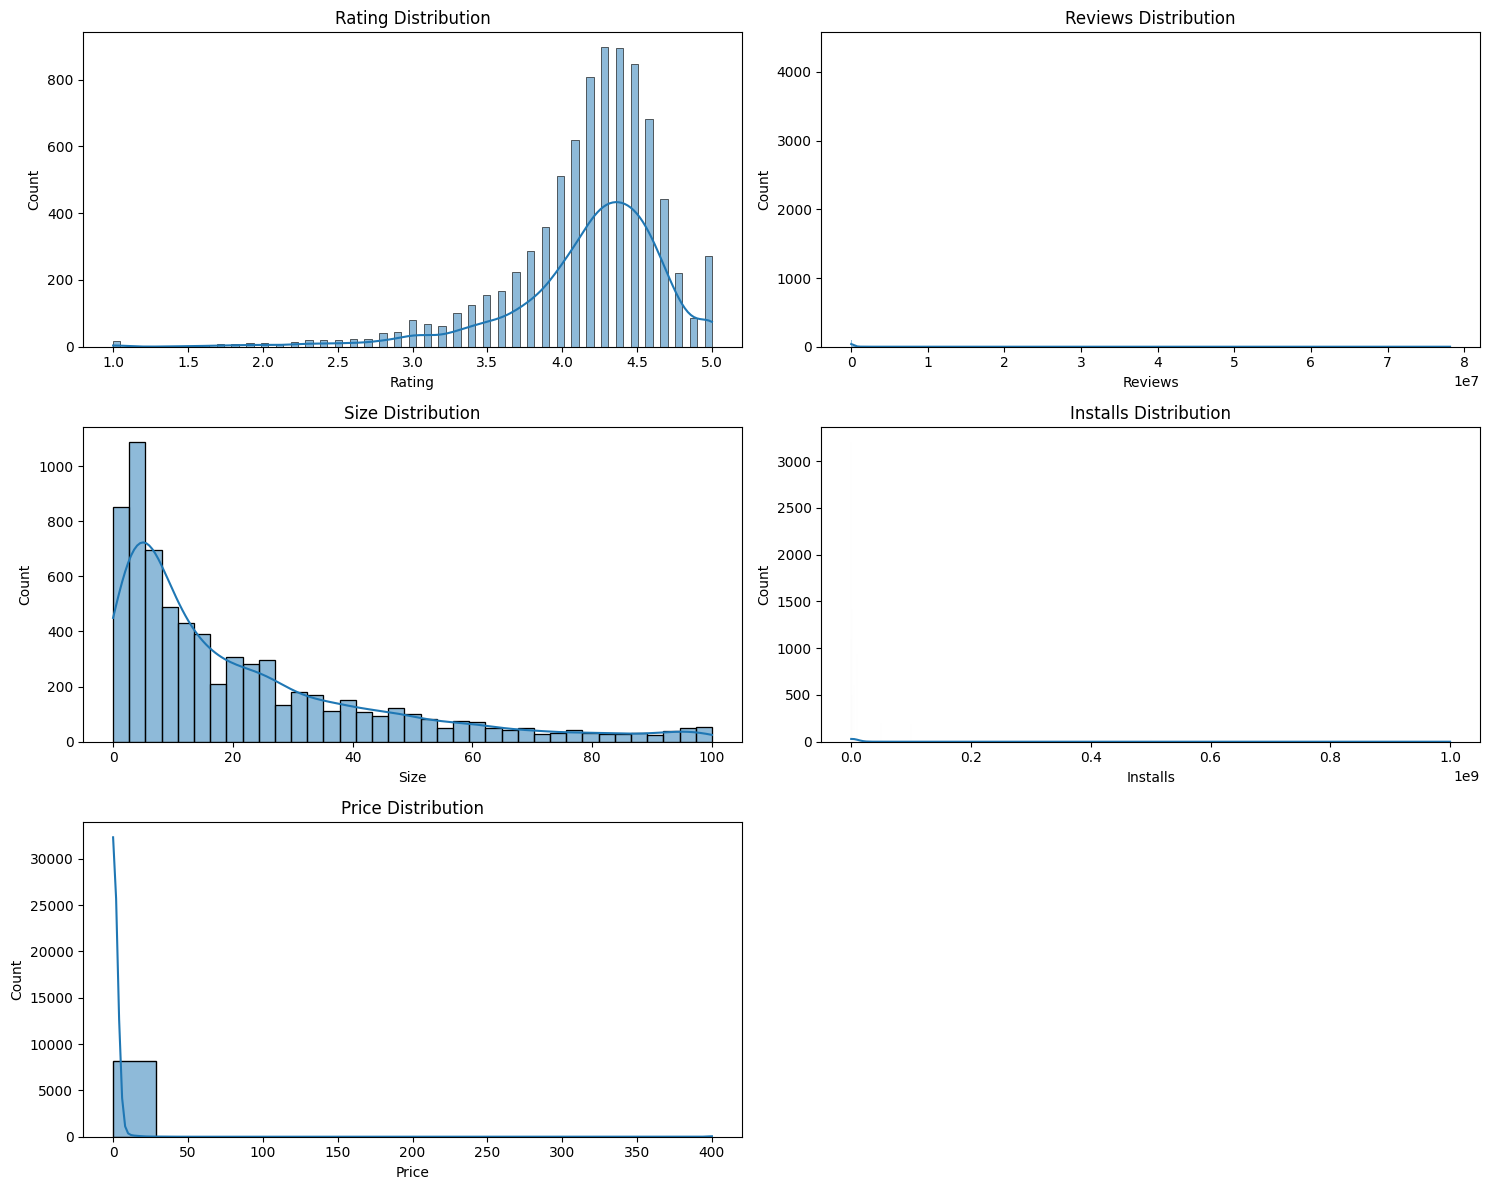

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

# Removing extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

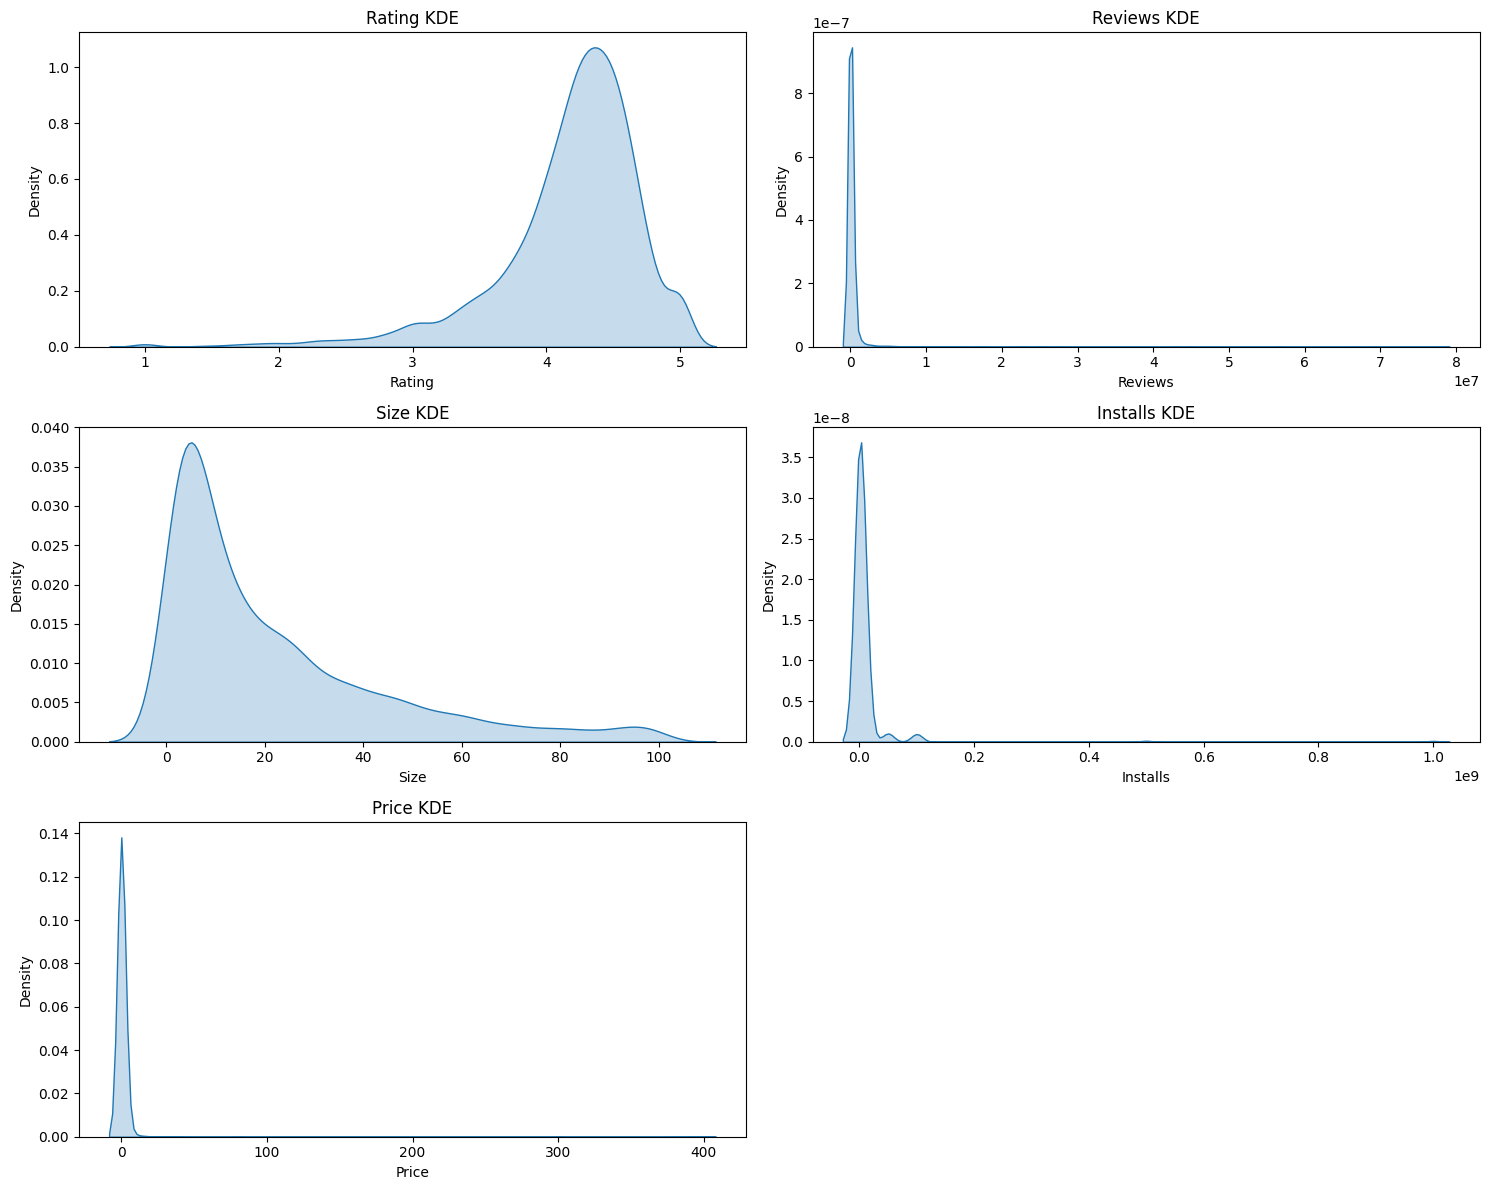

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], fill=True, ax=axes[i])
    axes[i].set_title(f'{col} KDE')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Descriptive Statistics Summary

### Rating
Mean rating is 4.17 while the median is 4.30.
Most apps are highly rated, indicating a slight left-skewed distribution.

### Reviews
The average number of reviews is 255K compared to a median of only 3K.
This suggests that a small number of apps receive the majority of user reviews.

### Installs
Average installs are 9.17 million while the median is only 100K.
The distribution is highly concentrated among a few very popular applications.

### Price
The median price is 0, with both Q1 and Q3 equal to 0.
This indicates that most applications on the Play Store are free.

### Size
The average app size is 21.77 MB while the median size is 13 MB.
Most apps are relatively small, with a few large applications increasing the average.

## Key Findings

- Most apps maintain ratings above 4.0.
- User engagement is concentrated among a small number of apps.
- App downloads follow a winner-takes-most pattern.
- Free apps dominate the Play Store ecosystem.
- Most applications are lightweight, with a few large apps creating the upper tail.

In [55]:
df[num_cols].kurt()

,0
Rating,5.121570
Reviews,771.076567
Size,1.788712
Installs,216.183390
Price,534.125521


### Kurtosis Analysis

#### Rating (5.12)
Slightly heavy-tailed distribution.
A few unusually low-rated apps exist, but nothing extreme.

#### Reviews (771.08)
Extremely high kurtosis.
A handful of apps have review counts far above the rest, creating massive outliers.

#### Size (1.79)
Relatively moderate distribution.
Some larger apps exist, but outliers are not severe.

#### Installs (216.18)
Extremely heavy-tailed distribution.
A small number of apps dominate total installs.

#### Price (534.13)
Extremely high kurtosis.
Most apps are free while a few expensive apps create significant outliers.

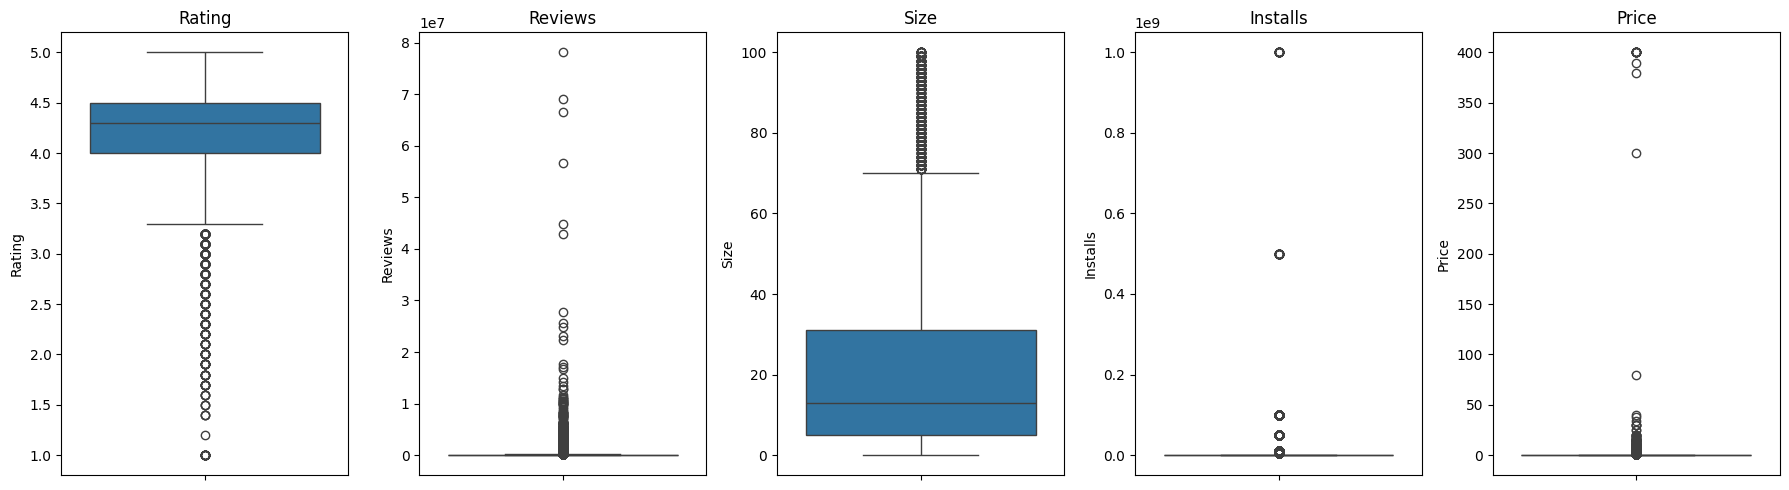

In [56]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Correlation Analysis

In [57]:
corr_cols = [
    'Rating',
    'Reviews',
    'Size',
    'Installs',
    'Price',
    'Sentiment_Polarity',
    'Sentiment_Subjectivity'
]

df[corr_cols].corr(numeric_only=True)

,Rating,Reviews,Size,Installs,Price,Sentiment_Polarity,Sentiment_Subjectivity
Rating,1.000000,0.055074,0.062967,0.040128,-0.021216,0.264102,0.215598
Reviews,0.055074,1.000000,0.180476,0.624050,-0.007792,-0.123300,-0.001015
Size,0.062967,0.180476,1.000000,0.131696,-0.025747,-0.323101,0.017326
Installs,0.040128,0.624050,0.131696,1.000000,-0.009657,-0.108530,0.013644
Price,-0.021216,-0.007792,-0.025747,-0.009657,1.000000,0.023668,-0.003544
Sentiment_Polarity,0.264102,-0.123300,-0.323101,-0.108530,0.023668,1.000000,0.319667
Sentiment_Subjectivity,0.215598,-0.001015,0.017326,0.013644,-0.003544,0.319667,1.000000


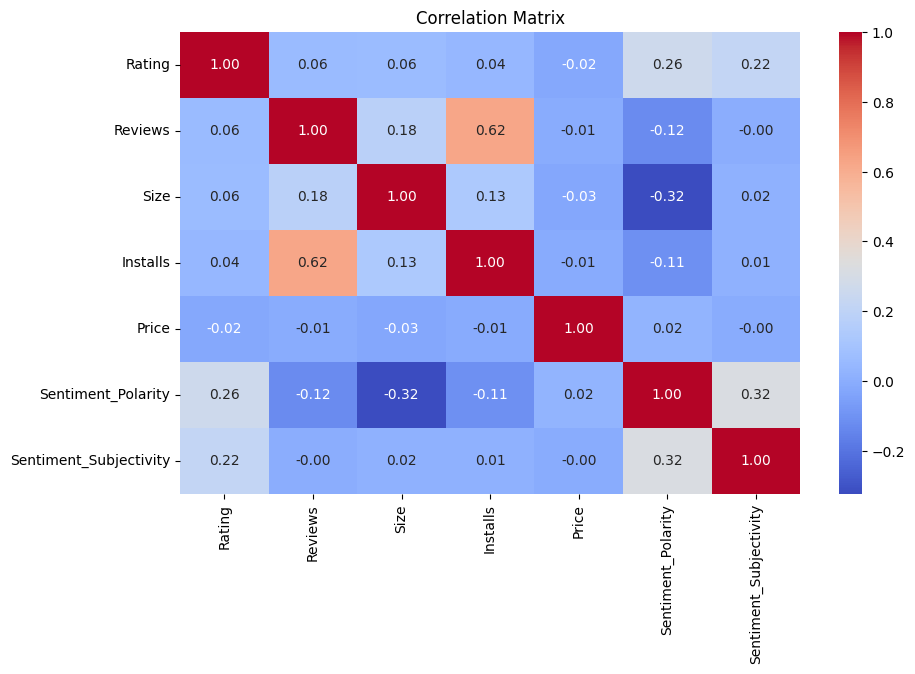

In [58]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[corr_cols].corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

## Correlation Analysis

- Reviews and Installs show a strong positive correlation (0.62), indicating that apps with more reviews generally receive more downloads.

- Rating has very weak correlation with Installs (0.04), suggesting that higher ratings do not necessarily translate into significantly more downloads.

- Size has a weak positive relationship with Installs (0.13), indicating app size is not a major driver of popularity.

- Price has almost no correlation with Installs (-0.01), suggesting paid status alone does not strongly influence downloads.

- Sentiment Polarity shows a moderate positive correlation with Rating (0.26), indicating apps receiving more positive reviews tend to have higher ratings.

- Sentiment Polarity and Size show a moderate negative correlation (-0.32), suggesting larger apps may receive slightly less positive sentiment.

Inferential Statistics

In [59]:
from scipy.stats import ttest_ind

### Hypothesis Test: Free vs Paid App Ratings

H₀ (Null Hypothesis):
The mean rating of Free apps is equal to the mean rating of Paid apps.

H₁ (Alternative Hypothesis):
The mean rating of Free apps is different from the mean rating of Paid apps.

In [60]:
free = df[df['Type']=='Free']['Rating']
paid = df[df['Type']=='Paid']['Rating']

In [61]:
print("Free Rating Mean :", free.mean())
print("Paid Rating Mean :", paid.mean())

Free Rating Mean : 4.166468960063266
Paid Rating Mean : 4.259800664451827


In [62]:
t_stat, p_value = ttest_ind(free, paid)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -4.1107169384358535
P Value: 3.982842116283643e-05


In [63]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


The p-value is less than 0.05 indicating a statistically significant difference between the ratings of Free and Paid apps. Therefore we reject the null hypothesis.

### T-Test: Free vs Paid App Ratings

Free Apps Mean Rating: 4.17

Paid Apps Mean Rating: 4.26

T-Statistic: -4.11

P-Value: 0.00004

Since the p-value is less than 0.05, we reject the null hypothesis.

There is a statistically significant difference between the ratings of Free and Paid apps.

In [64]:
from scipy.stats import f_oneway

In [65]:
groups = [group['Rating'].values
    for name, group in df.groupby('Category')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 7.032878804463038
P-value: 2.1969751338915636e-30


### ANOVA: Ratings Across Categories

Q - Do ratings differ across app categories?

F-Statistic: 7.03

P-Value: 2.20e-30

Since the p-value is less than 0.05, we reject the null hypothesis.

There is a statistically significant difference in ratings across app categories.

In [66]:
cat_rating = (
    df.groupby('Category')['Rating']
      .agg(['count','mean'])
      .sort_values('mean', ascending=False)
)

cat_rating.head(10)

,count,mean
Category,,
EVENTS,45,4.435556
ART_AND_DESIGN,60,4.376667
EDUCATION,118,4.364407
BOOKS_AND_REFERENCE,169,4.344970
PERSONALIZATION,296,4.331419
PARENTING,50,4.300000
BEAUTY,42,4.278571
GAME,912,4.247368
SOCIAL,203,4.247291


In [67]:
df.groupby('Category')['Installs'].mean().sort_values(ascending=False)

,Installs
Category,
COMMUNICATION,4.311813e+07
SOCIAL,2.703370e+07
VIDEO_PLAYERS,2.653241e+07
ENTERTAINMENT,2.072216e+07
PRODUCTIVITY,1.924608e+07
PHOTOGRAPHY,1.767735e+07
TRAVEL_AND_LOCAL,1.548053e+07
GAME,1.521794e+07
NEWS_AND_MAGAZINES,1.161329e+07


## Category Performance Analysis

### Highest Rated Categories

- Events (4.44)
- Art & Design (4.38)
- Education (4.36)
- Books & Reference (4.34)
- Personalization (4.33)

These categories consistently receive strong user satisfaction and positive ratings.

### Highest Install Categories

- Communication (43.1M)
- Social (27.0M)
- Video Players (26.5M)
- Entertainment (20.7M)
- Productivity (19.2M)

These categories dominate user adoption and market reach.

In [68]:
pd.crosstab(df['Type'], df['Content Rating'])

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen
Type,,,,,
Free,3,6101,274,342,867
Paid,0,511,31,15,45


In [69]:
from scipy.stats import chi2_contingency

In [70]:
table = pd.crosstab(df['Type'], df['Content Rating'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0011361362376679934


### Chi-Square Test: Type vs Content Rating

H₀: App Type (Free/Paid) and Content Rating are independent.

H₁: App Type (Free/Paid) and Content Rating are associated.

P-Value = 0.0011

Since the p-value is less than 0.05, we reject the null hypothesis.

There is a statistically significant association between App Type and Content Rating.

Top Categories by Installs

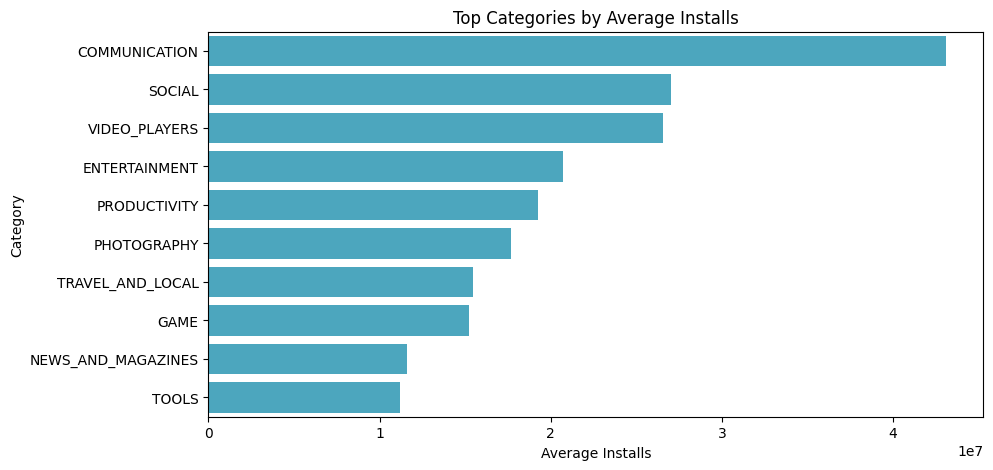

In [71]:
top_installs = (
    df.groupby('Category')['Installs']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_installs.values,
            y=top_installs.index, color='#39B1D1')

plt.title('Top Categories by Average Installs')
plt.xlabel('Average Installs')
plt.ylabel('Category')
plt.show()

Top Categories by Rating

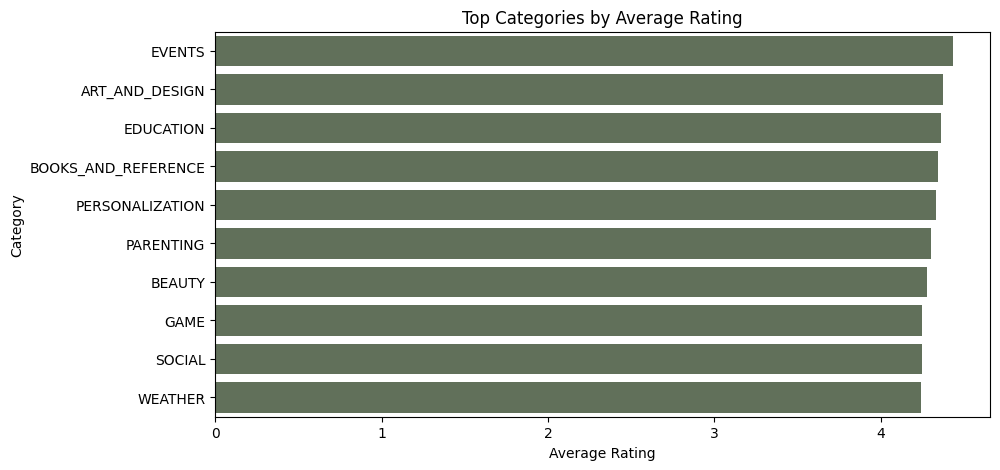

In [72]:
top_ratings = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_ratings.values,
            y=top_ratings.index, color='#607456')

plt.title('Top Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

Free vs Paid Rating Boxplot

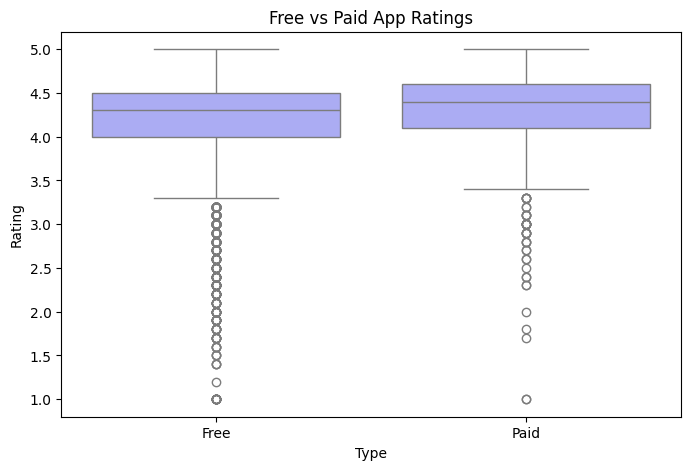

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Type',
    y='Rating',
    color = '#9FA1FF'
)

plt.title('Free vs Paid App Ratings')
plt.show()

Reviews vs Installs Scatterplot

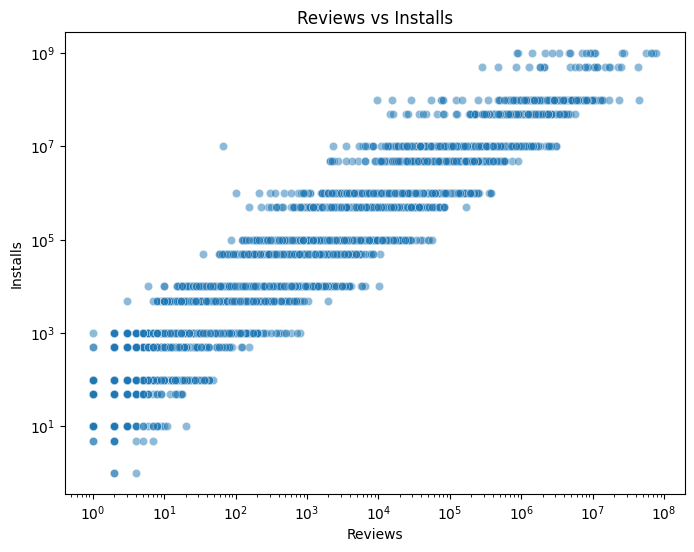

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs',
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.title('Reviews vs Installs')
plt.show()

Sentiment vs Rating Scatterplot

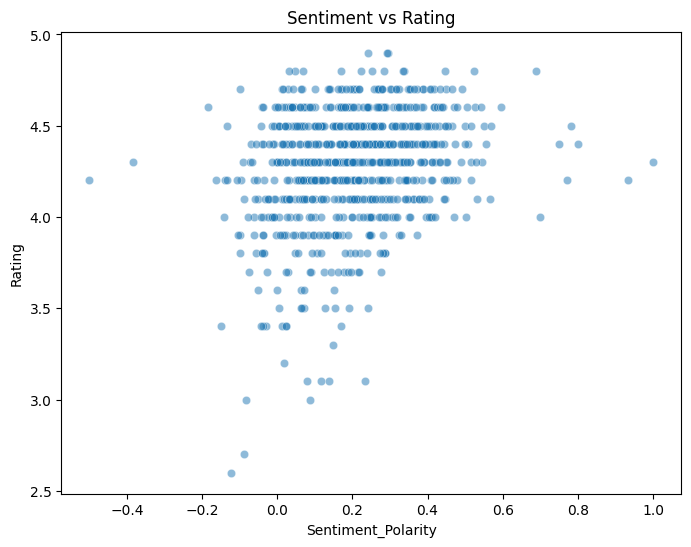

In [75]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Sentiment_Polarity',
    y='Rating',
    alpha=0.5
)

plt.title('Sentiment vs Rating')
plt.show()

Category-wise Rating Distribution

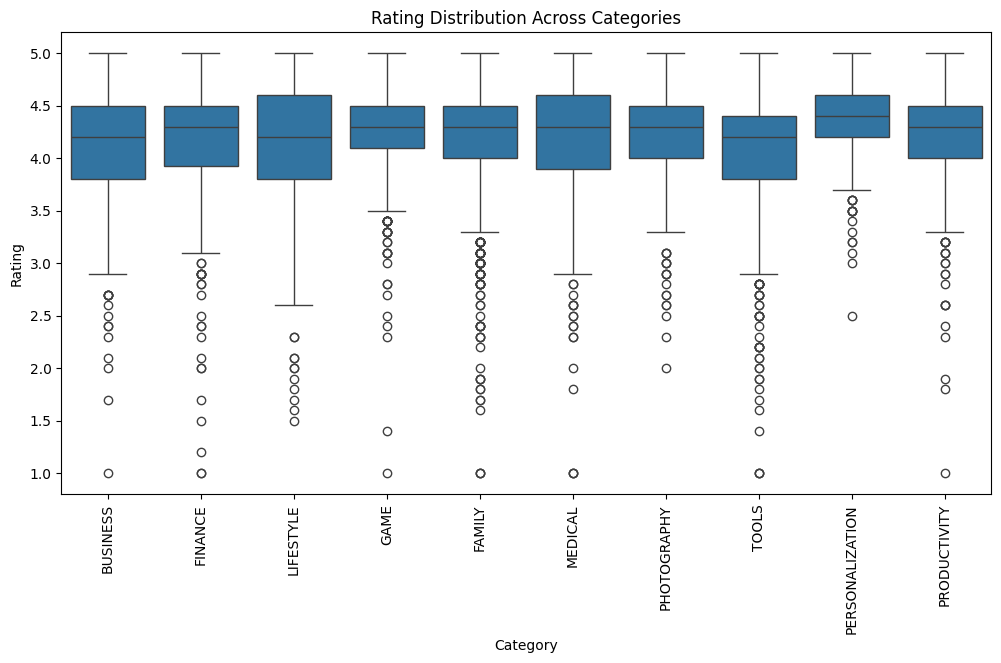

In [76]:
top_cat = (
    df['Category']
      .value_counts()
      .head(10)
      .index
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[df['Category'].isin(top_cat)],
    x='Category',
    y='Rating'
)

plt.xticks(rotation=90)
plt.title('Rating Distribution Across Categories')
plt.show()

In [77]:
df.to_csv('googleplaystore_cleaned.csv',index=False)

In [78]:
df.to_excel('googleplaycleaneddf.xlsx', index=False)

# 💼 Business Insights & Recommendations

## 1. Communication and Social Apps Demonstrate the Highest Growth Potential

### Evidence

Communication applications recorded the highest average install count at approximately **43.1 million installs**, followed by Social applications at **27.0 million installs**.

### Recommendation

Developers seeking large-scale user adoption should prioritize categories with broad daily usage and strong network effects. Communication and Social applications appear to offer the greatest potential for rapid user acquisition and market reach.


## 2. Paid Apps Receive Significantly Higher Ratings

### Evidence

The average rating for paid applications was **4.26**, compared to **4.17** for free applications. An independent t-test produced a **p-value < 0.05**, indicating that the difference is statistically significant.

### Recommendation

Developers targeting niche or premium audiences may benefit from a paid or subscription-based model. Users may associate paid applications with higher quality, reliability, or reduced advertising.


## 3. User Reviews Are Strongly Associated with App Adoption

### Evidence

Reviews and installs showed a strong positive correlation of approximately **0.62**, indicating that applications with more reviews tend to have significantly higher install counts.

### Recommendation

Product teams should actively encourage user feedback and reviews through in-app prompts and engagement campaigns. Increasing review volume may improve credibility, visibility, and long-term growth.



## 4. App Ratings Vary Significantly Across Categories

### Evidence

A one-way ANOVA test produced a **p-value of 2.20 × 10⁻³⁰**, indicating statistically significant differences in ratings across categories.

### Recommendation

Developers should benchmark their application's performance against competitors within the same category rather than comparing ratings across the entire Play Store. User expectations differ substantially by category.



## 5. Most Successful Apps Follow a Free Distribution Model

### Evidence

More than **75% of applications were free**, with the median app price equal to **0**. The price distribution exhibited a strong right skew, indicating that only a small proportion of applications are paid.

### Recommendation

For developers focused on maximizing user acquisition, a freemium strategy supported by advertisements, subscriptions, or in-app purchases may be more effective than relying solely on paid downloads.


## 6. App Success Is Influenced by Multiple Factors

### Evidence

The Random Forest model identified **Size**, **Price**, **App Type**, and **Category** among the most influential predictors of app success.

### Recommendation

Developers should evaluate multiple aspects of an application simultaneously rather than focusing on a single metric. Category selection, pricing strategy, and application characteristics collectively contribute to market performance.


## Key Takeaway

The analysis suggests that app success is not determined by a single factor. Category selection, pricing strategy, user engagement, and application characteristics all play important roles in driving installs and user satisfaction. Developers who align their products with high-demand categories, encourage user engagement, and adopt suitable monetization strategies are more likely to achieve long-term success on the Google Play Store.
